# Men's Model

This notebook makes the machine learning model. Remember to uncomment the last cell if you wouldlike to save the model. 

In [1]:
import pandas as pd

pd.set_option('display.max_columns', 100)

df_mod = pd.read_parquet(r'..\data\preprocessed\model_data\model_data.parquet')

df_mod

,Season,Round,Result,Team A ID,Team A,Team B ID,Team B,Past Year Tournament Result,Past 4 Years Tournament Results,WIN%,ADJOE,ADJDE,ADJEM,BARTHAG,EFG%,EFGD%,TOR,TORD,ORB,FTR,FTRD,ADJ T.,WAB,Past Year BARTHAG,Past 4 Years BARTHAG,Past Year ADJEM,Past 4 Years ADJEM,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo,Starters,Mu,OS Rating,Team A ADJOE Team B ADJDE,Team B ADJOE Team A ADJDE,Team A Offense Team B Defense,Team B Offense Team A Defense,Team A BARTHAG,Team B BARTHAG
0,2012,1,1,1124,Baylor,1355,S Dakota St,0.0,1.250000,0.006629,2.7,-7.1,9.8,0.1420,-1.2,-2.7,5.0,2.1,7.1,-3.4,2.2,0.4,7.4,0.0703,0.428300,2.4,20.000,2.338760,0.067615,0.002898,-0.064718,0.583440,0.117964,7.605073,7.704642,215.1,205.3,2.102757,2.035141,0.9090,0.7670
1,2012,1,1,1160,Colorado,1424,UNLV,-1.0,-1.000000,-0.093750,-5.1,1.9,-7.0,-0.1138,-3.9,0.9,-0.3,-2.3,-3.3,7.2,-0.9,-4.0,-3.1,-0.0848,-0.168775,-4.6,-8.075,-1.031018,-0.086742,-0.061467,0.025275,-3.751519,-0.226425,-7.098771,-6.444547,196.5,203.5,1.942409,2.029151,0.7615,0.8753
2,2012,1,1,1211,Gonzaga,1452,West Virginia,0.0,-0.750000,0.212702,-0.3,-1.2,0.9,0.0132,4.7,-2.8,0.6,-0.7,-6.4,8.9,-4.7,0.7,2.3,-0.0286,-0.026625,-3.0,-2.850,0.274774,0.029706,0.004889,-0.024816,0.670748,0.164332,6.727094,5.540592,206.1,205.2,2.033816,2.004111,0.8612,0.8480
3,2012,1,1,1231,Indiana,1308,New Mexico St,0.0,0.000000,0.030303,13.0,-0.9,13.9,0.1917,4.0,-0.1,-1.6,-0.1,-5.2,-6.2,1.0,-3.3,7.6,0.1886,0.008000,7.6,1.450,1.508085,0.104455,0.097244,-0.007210,-3.018990,0.115812,7.908734,8.270663,216.5,202.6,2.116803,2.012348,0.9184,0.7267
4,2012,1,1,1235,Iowa St,1163,Connecticut,-7.0,-3.250000,0.081439,0.9,1.0,-0.1,-0.0023,2.7,3.9,-0.8,0.7,-4.6,4.3,0.8,3.0,1.4,-0.1929,-0.200225,-13.4,-13.550,0.155641,0.007995,0.021385,0.013390,2.322124,-0.035981,3.232739,3.208781,205.5,205.6,2.038216,2.030221,0.8553,0.8576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,2024,4,-1,1181,Duke,1301,NC State,1.0,2.000000,0.138889,6.8,-4.4,11.2,0.1313,4.5,-1.5,0.6,-1.0,3.2,1.3,-4.3,-1.1,4.0,0.0800,0.136625,6.0,10.200,0.102572,0.121062,0.073952,-0.047109,-0.912177,0.151976,5.024188,4.103541,222.1,210.9,2.206684,2.085623,0.9262,0.7949
1506,2024,4,-1,1397,Tennessee,1345,Purdue,2.0,0.333333,-0.128788,-10.6,-3.5,-7.1,-0.0265,-4.5,-2.3,-1.9,4.9,-5.0,-8.5,12.8,1.6,-5.2,0.0068,-0.016675,-0.5,-1.725,-0.279607,-0.035856,-0.077972,-0.042117,1.337846,-0.133075,-5.394708,-4.408191,210.3,217.4,2.099227,2.135083,0.9375,0.9640
1507,2024,5,-1,1104,Alabama,1163,Connecticut,-4.0,-0.666667,-0.255515,-1.7,8.2,-9.9,-0.0577,-0.8,4.8,1.1,-0.6,-1.6,1.9,7.1,8.0,-7.5,-0.0095,-0.001675,-3.2,-0.525,-0.392997,-0.059663,0.001401,0.061064,7.406847,-0.265038,-11.210705,-10.392373,219.0,228.9,2.178061,2.237724,0.9115,0.9692
1508,2024,5,-1,1301,NC State,1345,Purdue,0.0,-1.333333,-0.267677,-12.1,6.5,-18.6,-0.1691,-5.3,2.8,-2.8,3.9,-8.8,-10.3,8.9,0.3,-11.7,-0.1061,-0.129800,-9.8,-9.200,-1.249299,-0.166874,-0.105671,0.061203,0.461882,-0.364008,-13.341988,-11.774469,208.8,227.4,2.071529,2.238403,0.7949,0.9640


In [2]:
# df_mod = df_mod.loc[:, ~df_mod.columns.isin(['7OT', 'BWE', 'COL', 'DCI',
#        'DII', 'DOK', 'DOL', 'DUN', 'EBP', 'KPK', 'KRA', 'LMC', 'LOG', 'MOR',
#        'POM', 'RT', 'RTH', 'RTP', 'SAG', 'SEL', 'SFX', 'SPR', 'STH', 'TPR',
#        'TRK', 'WIL', 'WLK', 'WOL'])]

df_mod

,Season,Round,Result,Team A ID,Team A,Team B ID,Team B,Past Year Tournament Result,Past 4 Years Tournament Results,WIN%,ADJOE,ADJDE,ADJEM,BARTHAG,EFG%,EFGD%,TOR,TORD,ORB,FTR,FTRD,ADJ T.,WAB,Past Year BARTHAG,Past 4 Years BARTHAG,Past Year ADJEM,Past 4 Years ADJEM,Rating,Efficiency Margin,Adjusted Offense,Adjusted Defense,Adjusted Tempo,Starters,Mu,OS Rating,Team A ADJOE Team B ADJDE,Team B ADJOE Team A ADJDE,Team A Offense Team B Defense,Team B Offense Team A Defense,Team A BARTHAG,Team B BARTHAG
0,2012,1,1,1124,Baylor,1355,S Dakota St,0.0,1.250000,0.006629,2.7,-7.1,9.8,0.1420,-1.2,-2.7,5.0,2.1,7.1,-3.4,2.2,0.4,7.4,0.0703,0.428300,2.4,20.000,2.338760,0.067615,0.002898,-0.064718,0.583440,0.117964,7.605073,7.704642,215.1,205.3,2.102757,2.035141,0.9090,0.7670
1,2012,1,1,1160,Colorado,1424,UNLV,-1.0,-1.000000,-0.093750,-5.1,1.9,-7.0,-0.1138,-3.9,0.9,-0.3,-2.3,-3.3,7.2,-0.9,-4.0,-3.1,-0.0848,-0.168775,-4.6,-8.075,-1.031018,-0.086742,-0.061467,0.025275,-3.751519,-0.226425,-7.098771,-6.444547,196.5,203.5,1.942409,2.029151,0.7615,0.8753
2,2012,1,1,1211,Gonzaga,1452,West Virginia,0.0,-0.750000,0.212702,-0.3,-1.2,0.9,0.0132,4.7,-2.8,0.6,-0.7,-6.4,8.9,-4.7,0.7,2.3,-0.0286,-0.026625,-3.0,-2.850,0.274774,0.029706,0.004889,-0.024816,0.670748,0.164332,6.727094,5.540592,206.1,205.2,2.033816,2.004111,0.8612,0.8480
3,2012,1,1,1231,Indiana,1308,New Mexico St,0.0,0.000000,0.030303,13.0,-0.9,13.9,0.1917,4.0,-0.1,-1.6,-0.1,-5.2,-6.2,1.0,-3.3,7.6,0.1886,0.008000,7.6,1.450,1.508085,0.104455,0.097244,-0.007210,-3.018990,0.115812,7.908734,8.270663,216.5,202.6,2.116803,2.012348,0.9184,0.7267
4,2012,1,1,1235,Iowa St,1163,Connecticut,-7.0,-3.250000,0.081439,0.9,1.0,-0.1,-0.0023,2.7,3.9,-0.8,0.7,-4.6,4.3,0.8,3.0,1.4,-0.1929,-0.200225,-13.4,-13.550,0.155641,0.007995,0.021385,0.013390,2.322124,-0.035981,3.232739,3.208781,205.5,205.6,2.038216,2.030221,0.8553,0.8576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,2024,4,-1,1181,Duke,1301,NC State,1.0,2.000000,0.138889,6.8,-4.4,11.2,0.1313,4.5,-1.5,0.6,-1.0,3.2,1.3,-4.3,-1.1,4.0,0.0800,0.136625,6.0,10.200,0.102572,0.121062,0.073952,-0.047109,-0.912177,0.151976,5.024188,4.103541,222.1,210.9,2.206684,2.085623,0.9262,0.7949
1506,2024,4,-1,1397,Tennessee,1345,Purdue,2.0,0.333333,-0.128788,-10.6,-3.5,-7.1,-0.0265,-4.5,-2.3,-1.9,4.9,-5.0,-8.5,12.8,1.6,-5.2,0.0068,-0.016675,-0.5,-1.725,-0.279607,-0.035856,-0.077972,-0.042117,1.337846,-0.133075,-5.394708,-4.408191,210.3,217.4,2.099227,2.135083,0.9375,0.9640
1507,2024,5,-1,1104,Alabama,1163,Connecticut,-4.0,-0.666667,-0.255515,-1.7,8.2,-9.9,-0.0577,-0.8,4.8,1.1,-0.6,-1.6,1.9,7.1,8.0,-7.5,-0.0095,-0.001675,-3.2,-0.525,-0.392997,-0.059663,0.001401,0.061064,7.406847,-0.265038,-11.210705,-10.392373,219.0,228.9,2.178061,2.237724,0.9115,0.9692
1508,2024,5,-1,1301,NC State,1345,Purdue,0.0,-1.333333,-0.267677,-12.1,6.5,-18.6,-0.1691,-5.3,2.8,-2.8,3.9,-8.8,-10.3,8.9,0.3,-11.7,-0.1061,-0.129800,-9.8,-9.200,-1.249299,-0.166874,-0.105671,0.061203,0.461882,-0.364008,-13.341988,-11.774469,208.8,227.4,2.071529,2.238403,0.7949,0.9640


Get monotonic constraints

In [3]:
df_mod.loc[df_mod['Round'] == 3, :].corr(numeric_only=True)['Result'].round(2)

Season                            -0.00
Round                               NaN
Result                             1.00
Team A ID                         -0.11
Team B ID                          0.11
Past Year Tournament Result        0.19
Past 4 Years Tournament Results    0.18
WIN%                               0.30
ADJOE                              0.33
ADJDE                             -0.07
ADJEM                              0.32
BARTHAG                            0.24
EFG%                               0.19
EFGD%                             -0.07
TOR                               -0.12
TORD                              -0.01
ORB                                0.11
FTR                                0.10
FTRD                              -0.05
ADJ T.                            -0.04
WAB                                0.37
Past Year BARTHAG                  0.23
Past 4 Years BARTHAG               0.25
Past Year ADJEM                    0.26
Past 4 Years ADJEM                 0.29


In [4]:
correlations = df_mod.corr(numeric_only=True)['Result']

correlations.round(2).head(50)

Season                             0.00
Round                              0.00
Result                             1.00
Team A ID                         -0.03
Team B ID                          0.03
Past Year Tournament Result        0.32
Past 4 Years Tournament Results    0.37
WIN%                               0.29
ADJOE                              0.43
ADJDE                             -0.38
ADJEM                              0.49
BARTHAG                            0.45
EFG%                               0.19
EFGD%                             -0.21
TOR                               -0.17
TORD                               0.05
ORB                                0.20
FTR                               -0.11
FTRD                              -0.13
ADJ T.                            -0.00
WAB                                0.47
Past Year BARTHAG                  0.43
Past 4 Years BARTHAG               0.41
Past Year ADJEM                    0.45
Past 4 Years ADJEM                 0.42


In [5]:
correlations.round(2).tail(50)

Season                             0.00
Round                              0.00
Result                             1.00
Team A ID                         -0.03
Team B ID                          0.03
Past Year Tournament Result        0.32
Past 4 Years Tournament Results    0.37
WIN%                               0.29
ADJOE                              0.43
ADJDE                             -0.38
ADJEM                              0.49
BARTHAG                            0.45
EFG%                               0.19
EFGD%                             -0.21
TOR                               -0.17
TORD                               0.05
ORB                                0.20
FTR                               -0.11
FTRD                              -0.13
ADJ T.                            -0.00
WAB                                0.47
Past Year BARTHAG                  0.43
Past 4 Years BARTHAG               0.41
Past Year ADJEM                    0.45
Past 4 Years ADJEM                 0.42


In [6]:
correlations.loc[correlations.abs() < 0.04].round(2)

Season            0.00
Round             0.00
Team A ID        -0.03
Team B ID         0.03
ADJ T.           -0.00
Adjusted Tempo    0.00
Name: Result, dtype: float64

In [7]:
monotone_constraints_dict = dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations > 0.04], 
    [1 for _ in range((correlations > 0.05).sum())]
))

monotone_constraints_dict.update(dict(zip(
    df_mod.drop(columns=['Team A', 'Team B']).columns[correlations < -0.04], 
    [-1 for _ in range((correlations < -0.05).sum())]
)))

del monotone_constraints_dict['Result']

monotone_constraints_dict

{'Past Year Tournament Result': 1,
 'Past 4 Years Tournament Results': 1,
 'WIN%': 1,
 'ADJOE': 1,
 'ADJEM': 1,
 'BARTHAG': 1,
 'EFG%': 1,
 'TORD': 1,
 'ORB': 1,
 'WAB': 1,
 'Past Year BARTHAG': 1,
 'Past 4 Years BARTHAG': 1,
 'Past Year ADJEM': 1,
 'Past 4 Years ADJEM': 1,
 'Rating': 1,
 'Efficiency Margin': 1,
 'Adjusted Offense': 1,
 'Starters': 1,
 'Mu': 1,
 'OS Rating': 1,
 'Team A ADJOE Team B ADJDE': 1,
 'Team A Offense Team B Defense': 1,
 'Team A BARTHAG': 1,
 'ADJDE': -1,
 'EFGD%': -1,
 'TOR': -1,
 'FTR': -1,
 'FTRD': -1,
 'Adjusted Defense': -1,
 'Team B ADJOE Team A ADJDE': -1,
 'Team B Offense Team A Defense': -1,
 'Team B BARTHAG': -1}

Create train-val-test folds

In [8]:
from sklearn.model_selection import GroupKFold
import numpy as np

np.random.seed(22)

gkf = GroupKFold(n_splits=3)

cv_data = []
for train_val_index, test_index in gkf.split(df_mod.index, groups=df_mod['Season']):
    df_train_val_iter = df_mod.loc[train_val_index, :]
    df_test_iter = df_mod.loc[test_index, :]

    val_seasons = np.random.choice(df_train_val_iter['Season'].unique(), size=3, replace=False)

    X_train_iter = (
        df_train_val_iter
        .loc[~df_train_val_iter['Season'].isin(val_seasons), :]
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )
    X_val_iter = (
        df_train_val_iter
        .loc[df_train_val_iter['Season'].isin(val_seasons), :]
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )
    X_test_iter = (
        df_test_iter
        .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
    )

    y_train_iter = (
        df_train_val_iter
        .loc[~df_train_val_iter['Season'].isin(val_seasons), 'Result']
    )
    y_val_iter = (
        df_train_val_iter
        .loc[df_train_val_iter['Season'].isin(val_seasons), 'Result']
    )
    y_test_iter = (
        df_test_iter['Result']
    )

    cv_data.append((
        X_train_iter, 
        X_val_iter, 
        X_test_iter, 
        y_train_iter, 
        y_val_iter, 
        y_test_iter,
    ))

len(cv_data)

3

In [9]:
monotone_constraints = [monotone_constraints_dict.get(c, 0) for c in X_train_iter.columns]

monotone_constraints

[0,
 1,
 1,
 1,
 1,
 -1,
 1,
 1,
 1,
 -1,
 -1,
 1,
 1,
 -1,
 -1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 -1,
 0,
 1,
 1,
 1,
 1,
 -1,
 1,
 -1,
 1,
 -1]

In [10]:
from sklearn.metrics import log_loss
from lightgbm import LGBMClassifier
import optuna
import numpy as np

def objective(trial, cv_data=cv_data):
    # model tuning
    params = {
        'random_state': 22,
        'metric': 'binary_logloss',
        'verbosity': -1,
        'n_estimators': 500,
        'early_stopping_round': 25,
        'monotone_constraints': monotone_constraints,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0),
        'max_depth': trial.suggest_int('max_depth', 1, 32),
        'num_leaves': trial.suggest_int('num_leaves', 2, 2**8),
        'feature_fraction': trial.suggest_float('feature_fraction', 1e-8, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 100),
    }
    mod = LGBMClassifier(**params)

    # cross validation
    y_actuals = []
    y_preds = []
    for X_train, X_val, X_test, y_train, y_val, y_test in cv_data:
        y_actuals.append(y_test)

        mod.fit(
            X_train, 
            y_train, 
            eval_set=(X_val, y_val),
        )

        y_preds.append(mod.predict_proba(X_test)[:, 1])

    return log_loss(np.hstack(y_actuals), np.hstack(y_preds))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=22, n_startup_trials=50, multivariate=True))
study.optimize(objective, n_trials=200, show_progress_bar=True)

study.best_params

c:\Users\mhugh\anaconda3\envs\clean2\lib\site-packages\optuna\_experimental.py:30: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-02-25 22:12:47,750] A new study created in memory with name: no-name-296c0e1c-73db-4529-aa5d-4a798bd7326f


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2025-02-25 22:12:48,052] Trial 0 finished with value: 0.5536753030649789 and parameters: {'lambda_l1': 2.084605381503821, 'lambda_l2': 4.816810622816848, 'max_depth': 14, 'num_leaves': 221, 'feature_fraction': 0.17116156190005774, 'min_child_samples': 34}. Best is trial 0 with value: 0.5536753030649789.
[I 2025-02-25 22:12:48,221] Trial 1 finished with value: 0.5521342749832662 and parameters: {'lambda_l1': 2.7053283402729833, 'lambda_l2': 6.910413507585547, 'max_depth': 8, 'num_leaves': 209, 'feature_fraction': 0.010526884210839693, 'min_child_samples': 57}. Best is trial 1 with value: 0.5521342749832662.
[I 2025-02-25 22:12:48,357] Trial 2 finished with value: 0.5608320811375497 and parameters: {'lambda_l1': 8.137261876014703, 'lambda_l2': 7.451002963137353, 'max_depth': 7, 'num_leaves': 3, 'feature_fraction': 0.7720438737240976, 'min_child_samples': 96}. Best is trial 1 with value: 0.5521342749832662.
[I 2025-02-25 22:12:48,606] Trial 3 finished with value: 0.5585613688954082 and

{'lambda_l1': 0.3893793819331601,
 'lambda_l2': 0.02292798605508073,
 'max_depth': 9,
 'num_leaves': 152,
 'feature_fraction': 0.025934156237843283,
 'min_child_samples': 69}

In [11]:
optuna.importance.get_param_importances(study)

{'lambda_l1': 0.7187313490395228,
 'feature_fraction': 0.17917112013598882,
 'min_child_samples': 0.06783189945306144,
 'max_depth': 0.011992605317839754,
 'lambda_l2': 0.011339468019005339,
 'num_leaves': 0.010933558034581653}

In [12]:
np.random.seed(22)

val_seasons = np.random.choice(df_train_val_iter['Season'].unique(), size=3, replace=False)

X_train = (
    df_mod
    .loc[~df_mod['Season'].isin(val_seasons), :]
    .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
)

X_val = (
    df_mod
    .loc[df_mod['Season'].isin(val_seasons), :]
    .drop(columns=['Season', 'Result', 'Team A ID', 'Team A', 'Team B ID', 'Team B'])
)

y_train = (
    df_mod
    .loc[~df_mod['Season'].isin(val_seasons), 'Result']
)

y_val = (
    df_mod
    .loc[df_mod['Season'].isin(val_seasons), 'Result']
)

X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1132, 35), (378, 35), (1132,), (378,))

In [13]:
params = (
    {
        'random_state': 22,
        'metric': 'binary_logloss',
        'verbosity': -1,
        'n_estimators': 500,
        'early_stopping_round': 25,
        'monotone_constraints': monotone_constraints,
    } |
    study.best_params
)

mod = LGBMClassifier(**params)

mod.fit(
    X_train, 
    y_train, 
    eval_set=(X_val, y_val),
)

LGBMClassifier(early_stopping_round=25, feature_fraction=0.025934156237843283,
               lambda_l1=0.3893793819331601, lambda_l2=0.02292798605508073,
               max_depth=9, metric='binary_logloss', min_child_samples=69,
               monotone_constraints=[0, 1, 1, 1, 1, -1, 1, 1, 1, -1, -1, 1, 1,
                                     -1, -1, 0, 1, 1, 1, 1, 1, 1, 1, 1, -1, 0,
                                     1, 1, 1, 1, ...],
               n_estimators=500, num_leaves=152, random_state=22, verbosity=-1)

In [14]:
mod.predict_proba(X_train)[:, 1]

array([0.72545728, 0.38326051, 0.54026435, ..., 0.22988711, 0.14031263,
       0.42758449])

In [15]:
import shap

explainer = shap.Explainer(mod, feature_names=X_train.columns, seed=22)

shap_values = explainer(X_train)

shap_values.shape

(1132, 35)

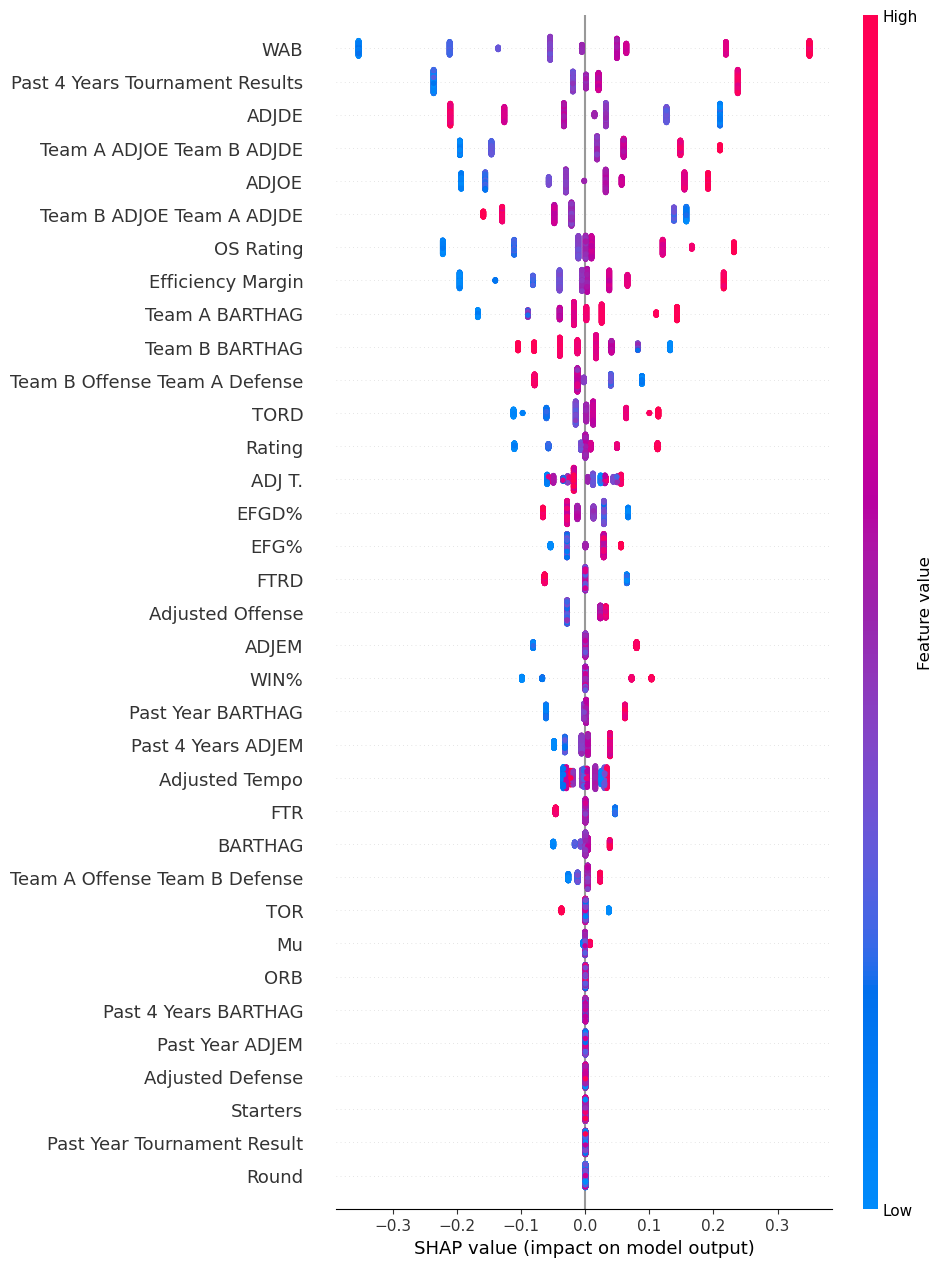

In [16]:
shap.plots.beeswarm(shap_values, max_display=None)

In [17]:
df_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': mod.feature_importances_,
}).sort_values(['Importance'], ascending=False, ignore_index=True)

df_feature_importance

,Feature,Importance
0,WAB,27
1,ADJ T.,24
2,ADJDE,21
3,OS Rating,21
4,TORD,19
5,Efficiency Margin,15
6,Past 4 Years Tournament Results,14
7,Team A BARTHAG,13
8,ADJOE,13
9,Rating,12


In [18]:
# import pickle

# with open('../model/mens_20240316/model.pkl', 'wb') as f:
#     pickle.dump(mod, f)

# df_mod.to_csv('../model/mens_20240316/df_mod.csv', index=False)

# 'Done'